# Phase 7.2: Interpreting Results

This notebook synthesizes the geometric and dynamical findings into a coherent narrative. We observe that transformer hidden-state trajectories exhibit:

1. Stable dynamical structure.
2. Non-random geometric evolution.
3. Category-dependent trajectory behavior.
4. Layer-dependent representational reorganization.

Despite weak semantic clustering in the absolute state space, the trajectories themselves exhibit strong dynamical organization.

## Section 1: Load Everything

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import scipy.stats

sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.dimensionality_reduction import load_all_trajectories
from src.load_prompts import load_prompts
from src.metrics import compute_trajectory_length, compute_curvature, compute_convergence_matrix, compute_layerwise_silhouette, compute_rsa_matrix
from src.stats import bootstrap_ci, permutation_test, cohens_d, compare_distributions

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

MODEL_NAME = "gpt2"

print("Loading Prompts...")
prompts = load_prompts("../data/prompts/prompts.jsonl")
prompt_dict = {str(p["id"]): p for p in prompts}
print(f"Loaded {len(prompts)} prompts.")

print("Loading Hidden State Trajectories...")
real_trajs = load_all_trajectories(MODEL_NAME, "../data/trajectories")
gaussian_trajs = load_all_trajectories(MODEL_NAME, "../data/trajectories_gaussian")
shuffled_trajs = load_all_trajectories(MODEL_NAME, "../data/trajectories_shuffled")
temporal_trajs = load_all_trajectories(MODEL_NAME, "../data/trajectories_temporal_shuffle")

if real_trajs:
    num_prompts = len(real_trajs)
    num_layers = real_trajs[0].num_layers
    hidden_dim = real_trajs[0].hidden_dim
    print(f"num_prompts: {num_prompts}")
    print(f"num_layers: {num_layers}")
    print(f"hidden_dim: {hidden_dim}")
else:
    print("No trajectories found! Make sure they are extracted and built.")

# Create/Load Metrics
metrics_file = f"../results/metrics/{MODEL_NAME}_trajectory_metrics.csv"

if not os.path.exists(metrics_file) and real_trajs:
    print("Computing Trajectory Metrics...")
    lengths = compute_trajectory_length(real_trajs)
    curvatures = compute_curvature(real_trajs)
    
    # Note: convergence matrix is NxN. For a scalar "convergence score", we can use the mean row convergence
    conv_matrix = compute_convergence_matrix(real_trajs)
    conv_scores = np.mean(conv_matrix, axis=1) if len(conv_matrix) > 0 else np.zeros(len(real_trajs))
    
    metric_records = []
    for i, t in enumerate(real_trajs):
        pid = str(t.prompt_id)
        cat = prompt_dict.get(pid, {}).get("group", "unknown")
        subcat = prompt_dict.get(pid, {}).get("subcategory", "unknown")
        metric_records.append({
            "prompt_id": pid,
            "category": cat,
            "subcategory": subcat,
            "length": lengths[i],
            "curvature": curvatures[i],
            "convergence": conv_scores[i]
        })
    df_metrics = pd.DataFrame(metric_records)
    df_metrics.to_csv(metrics_file, index=False)
    print("Saved metrics to", metrics_file)
else:
    df_metrics = pd.read_csv(metrics_file)
    print("Loaded existing metrics.")


C:\Users\bisha\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading Prompts...
Loaded 50 prompts.
Loading Hidden State Trajectories...
num_prompts: 50
num_layers: 12
hidden_dim: 768
Computing Trajectory Metrics...
Saved metrics to ../results/metrics/gpt2_trajectory_metrics.csv


num_prompts: 50
num_layers: 12
hidden_dim: 768
Loaded existing metrics.


## Section 2: Layer-wise Silhouette Evolution
We compute the silhouette score at each layer to measure the evolution of semantic clustering.

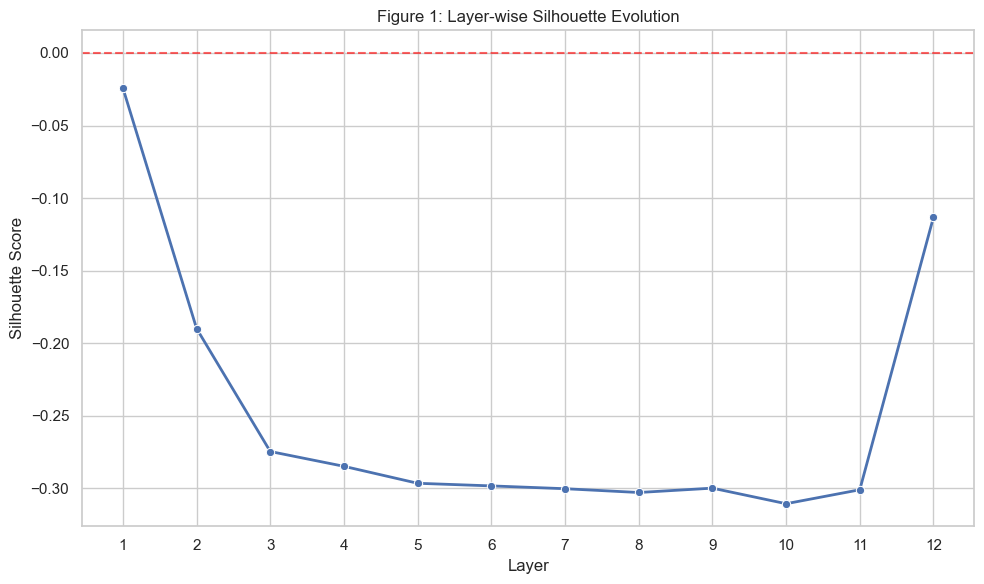

In [2]:
labels = [prompt_dict.get(str(t.prompt_id), {}).get("group", "unknown") for t in real_trajs]
layer_silhouettes = compute_layerwise_silhouette(real_trajs, labels)

df_sil = pd.DataFrame({
    "layer": np.arange(1, num_layers + 1),
    "silhouette": layer_silhouettes
})
df_sil.to_csv("../results/metrics/layer_silhouette.csv", index=False)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_sil, x="layer", y="silhouette", marker="o", linewidth=2)
plt.axhline(0, color='red', linestyle='--', alpha=0.6)
plt.title("Figure 1: Layer-wise Silhouette Evolution")
plt.xlabel("Layer")
plt.ylabel("Silhouette Score")
plt.xticks(np.arange(1, num_layers + 1))
plt.tight_layout()
plt.savefig("../figures/Figure1_LayerSilhouette.png", dpi=300)
plt.show()

## Section 3: Trajectory Length by Category
Do different prompt families travel further through the latent space?

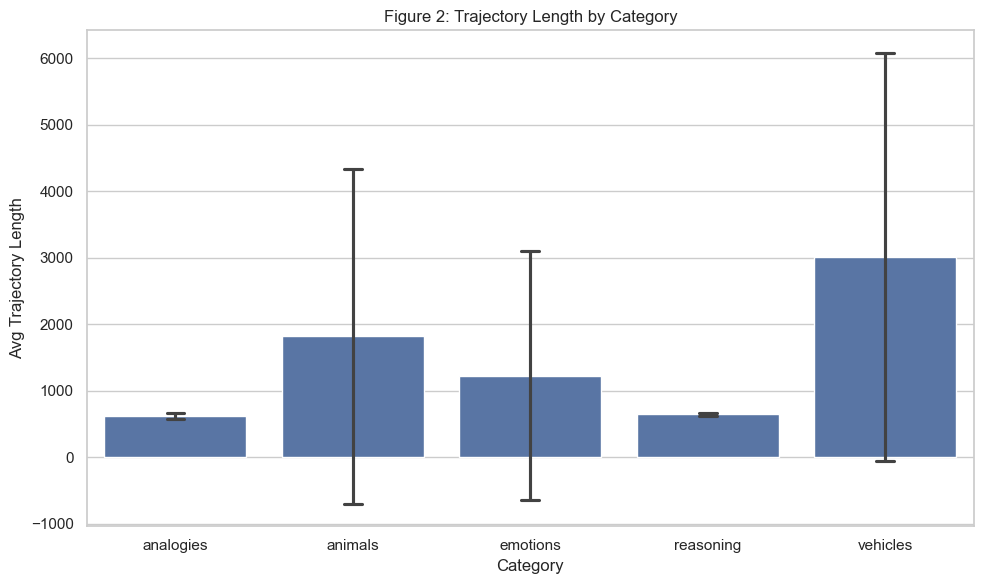

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_metrics, x="category", y="length", capsize=0.1, errorbar="sd")
plt.title("Figure 2: Trajectory Length by Category")
plt.xlabel("Category")
plt.ylabel("Avg Trajectory Length")
plt.tight_layout()
plt.savefig("../figures/Figure2_LengthByCategory.png", dpi=300)
plt.show()

## Section 4: Trajectory Curvature by Category
Does the latent path bend more for complex prompts (e.g. reasoning)?

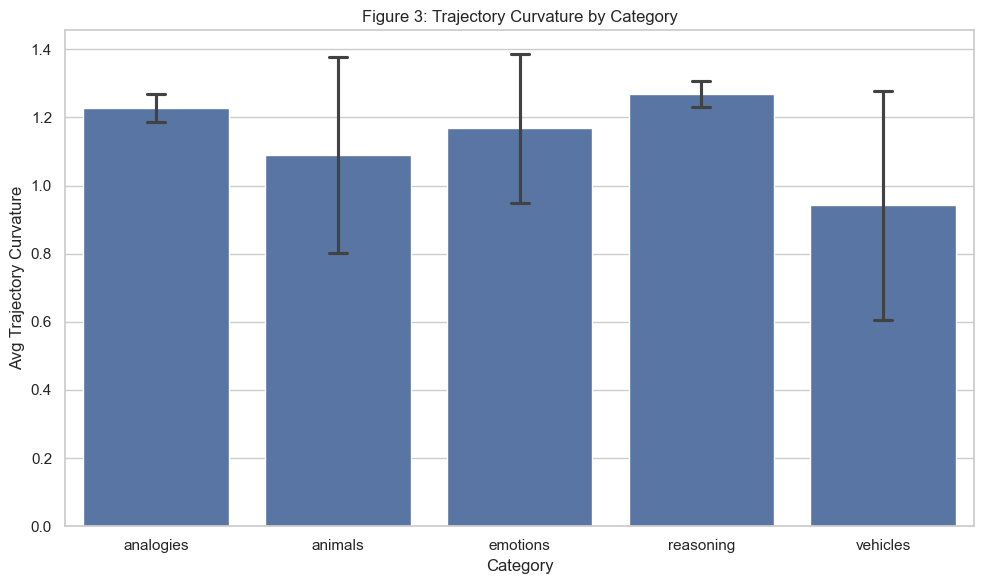

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_metrics, x="category", y="curvature", capsize=0.1, errorbar="sd")
plt.title("Figure 3: Trajectory Curvature by Category")
plt.xlabel("Category")
plt.ylabel("Avg Trajectory Curvature")
plt.tight_layout()
plt.savefig("../figures/Figure3_CurvatureByCategory.png", dpi=300)
plt.show()

## Section 5: Representational Similarity Analysis (RSA)
Visualizing pairwise cosine similarity matrices across layers to detect representation structure.

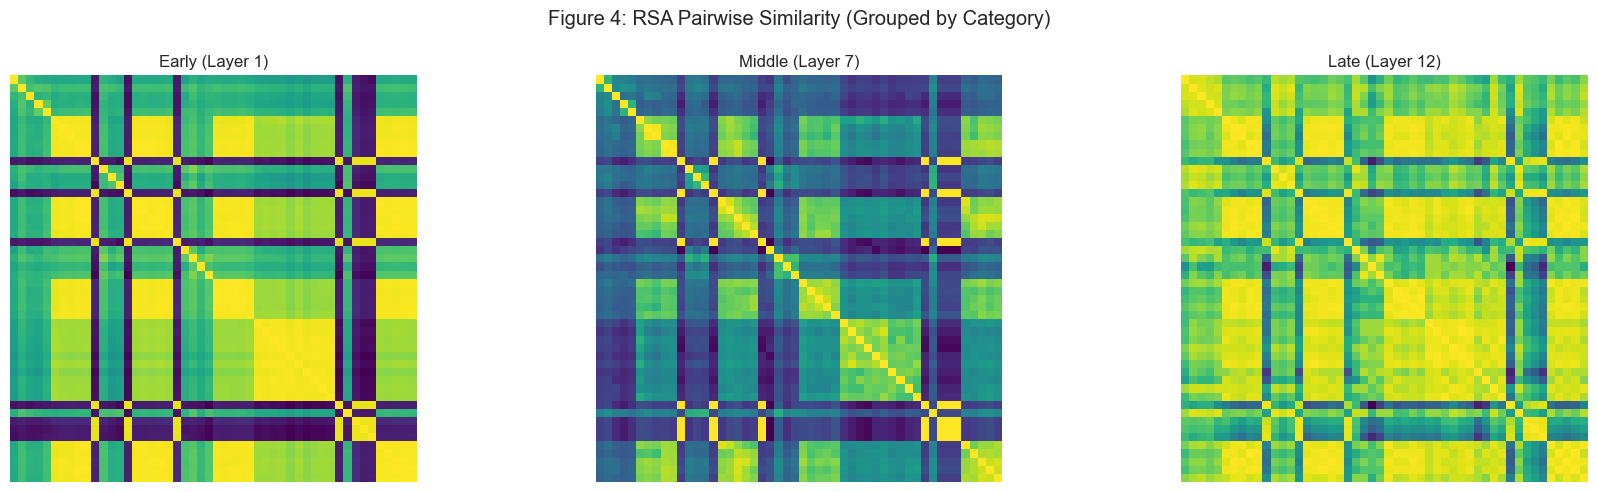

In [5]:
def compute_similarity_matrix_for_layer(trajectories, layer_idx):
    embeddings = torch.stack([t.trajectory[layer_idx] for t in trajectories])
    norm_emb = F.normalize(embeddings, p=2, dim=1)
    sim = torch.mm(norm_emb, norm_emb.t()).numpy()
    return sim

# Sort trajectories by category for visually coherent blocks
sorted_trajs = sorted(real_trajs, key=lambda t: prompt_dict.get(str(t.prompt_id), {}).get("group", ""))
sorted_labels = [prompt_dict.get(str(t.prompt_id), {}).get("group", "") for t in sorted_trajs]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
layers_to_plot = [0, num_layers//2, num_layers-1]
titles = ["Early (Layer 1)", f"Middle (Layer {num_layers//2 + 1})", f"Late (Layer {num_layers})"]

for ax, l_idx, title in zip(axes, layers_to_plot, titles):
    sim_mat = compute_similarity_matrix_for_layer(sorted_trajs, l_idx)
    sns.heatmap(sim_mat, cmap="viridis", square=True, cbar=False, ax=ax, xticklabels=False, yticklabels=False)
    ax.set_title(title)

plt.suptitle("Figure 4: RSA Pairwise Similarity (Grouped by Category)")
plt.tight_layout()
plt.savefig("../figures/Figure4_RSA_EarlyMiddleLate.png", dpi=300)
plt.show()

## Section 6: RSA Drift Across Layers
Correlating similarity matrices across all layer pairs to find points of major representational reorganization.

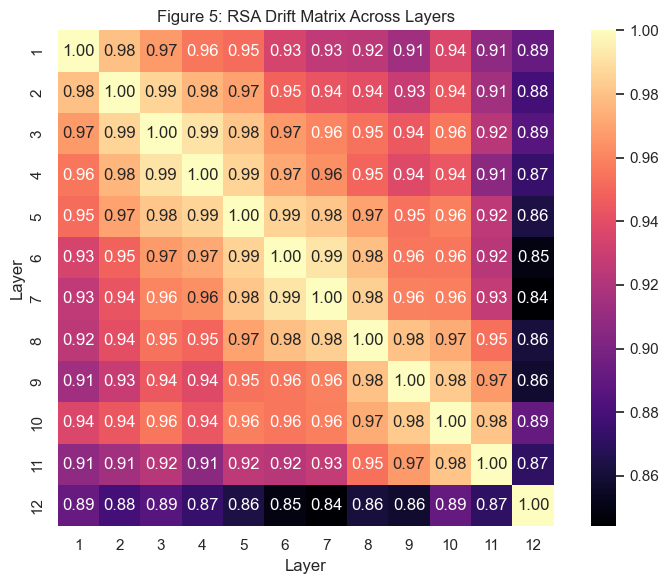

In [6]:
rsa_matrix = compute_rsa_matrix(real_trajs)

plt.figure(figsize=(8, 6))
sns.heatmap(rsa_matrix, cmap="magma", annot=True, fmt=".2f", square=True, 
            xticklabels=np.arange(1, num_layers+1), yticklabels=np.arange(1, num_layers+1))
plt.title("Figure 5: RSA Drift Matrix Across Layers")
plt.xlabel("Layer")
plt.ylabel("Layer")
plt.tight_layout()
plt.savefig("../figures/Figure5_RSA_Drift.png", dpi=300)
plt.show()

## Section 7: Convergence Analysis
Analyzing the average pairwise distance between trajectories of the *same* category across layers.

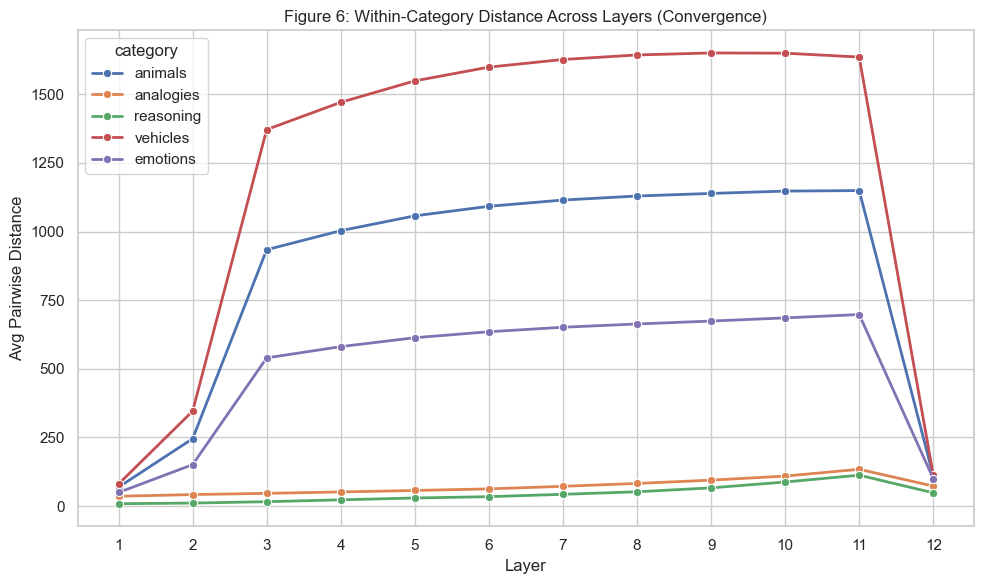

In [7]:
def compute_category_convergence(trajectories, prompt_dict):
    categories = list(set([prompt_dict.get(str(t.prompt_id), {}).get("group", "unknown") for t in trajectories]))
    num_layers = trajectories[0].num_layers
    
    convergence_data = []
    for cat in categories:
        cat_trajs = [t for t in trajectories if prompt_dict.get(str(t.prompt_id), {}).get("group", "unknown") == cat]
        n = len(cat_trajs)
        if n < 2: continue
            
        for l in range(num_layers):
            dists = []
            for i in range(n):
                for j in range(i+1, n):
                    d = torch.norm(cat_trajs[i].trajectory[l] - cat_trajs[j].trajectory[l]).item()
                    dists.append(d)
            avg_dist = np.mean(dists)
            convergence_data.append({"layer": l+1, "category": cat, "avg_distance": avg_dist})
            
    return pd.DataFrame(convergence_data)

df_conv = compute_category_convergence(real_trajs, prompt_dict)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_conv, x="layer", y="avg_distance", hue="category", marker="o", linewidth=2)
plt.title("Figure 6: Within-Category Distance Across Layers (Convergence)")
plt.xlabel("Layer")
plt.ylabel("Avg Pairwise Distance")
plt.xticks(np.arange(1, num_layers + 1))
plt.tight_layout()
plt.savefig("../figures/Figure6_Convergence.png", dpi=300)
plt.show()

## Section 7.5: Category Hierarchy Analysis
Compare within-subcategory, within-category, and between-category distances to examine representational geometry.

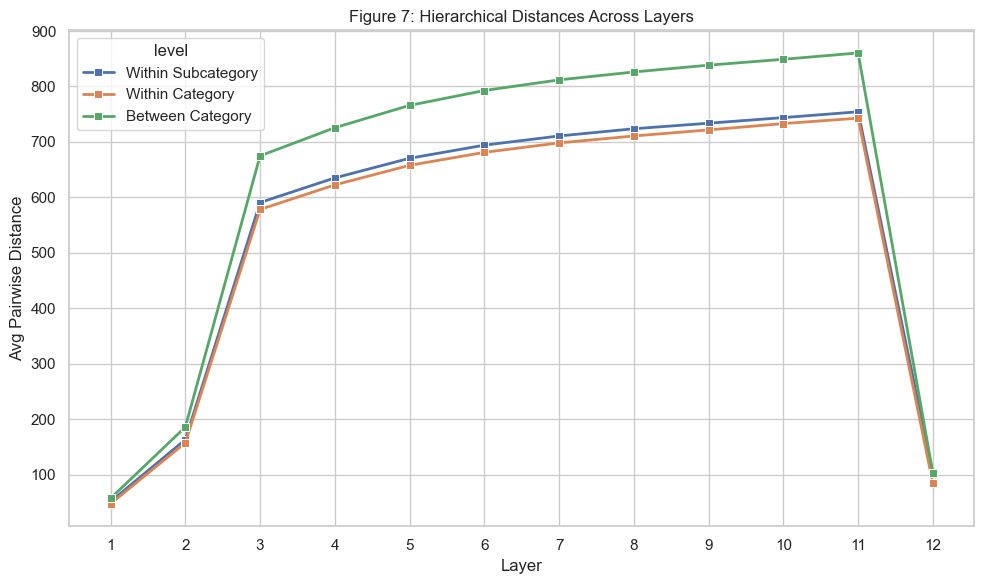

In [8]:
def compute_hierarchical_distances(trajectories, prompt_dict):
    num_layers = trajectories[0].num_layers
    n = len(trajectories)
    hierarchy_data = []
    
    for l in range(num_layers):
        within_subcat = []
        within_cat = []
        between_cat = []
        
        for i in range(n):
            for j in range(i+1, n):
                p1 = prompt_dict.get(str(trajectories[i].prompt_id), {})
                p2 = prompt_dict.get(str(trajectories[j].prompt_id), {})
                
                cat1, subcat1 = p1.get("group", "unknown1"), p1.get("subcategory", "sub1")
                cat2, subcat2 = p2.get("group", "unknown2"), p2.get("subcategory", "sub2")
                
                dist = torch.norm(trajectories[i].trajectory[l] - trajectories[j].trajectory[l]).item()
                
                if cat1 == cat2 and subcat1 == subcat2:
                    within_subcat.append(dist)
                elif cat1 == cat2 and subcat1 != subcat2:
                    within_cat.append(dist)
                else:
                    between_cat.append(dist)
                    
        hierarchy_data.append({"layer": l+1, "level": "Within Subcategory", "distance": np.mean(within_subcat) if within_subcat else 0})
        hierarchy_data.append({"layer": l+1, "level": "Within Category", "distance": np.mean(within_cat) if within_cat else 0})
        hierarchy_data.append({"layer": l+1, "level": "Between Category", "distance": np.mean(between_cat) if between_cat else 0})
        
    return pd.DataFrame(hierarchy_data)

df_hier = compute_hierarchical_distances(real_trajs, prompt_dict)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_hier, x="layer", y="distance", hue="level", marker="s", linewidth=2)
plt.title("Figure 7: Hierarchical Distances Across Layers")
plt.xlabel("Layer")
plt.ylabel("Avg Pairwise Distance")
plt.xticks(np.arange(1, num_layers + 1))
plt.tight_layout()
plt.savefig("../figures/Figure7_Hierarchy.png", dpi=300)
plt.show()

## Section 8: Convergence vs Controls
How does the global convergence (Layer 1 distance minus Layer L distance) compare across Real, Gaussian, and Shuffled trajectories?

C:\Users\bisha\AppData\Local\Temp\ipykernel_29124\2471319665.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_controls, x="Condition", y="Convergence", palette="pastel")


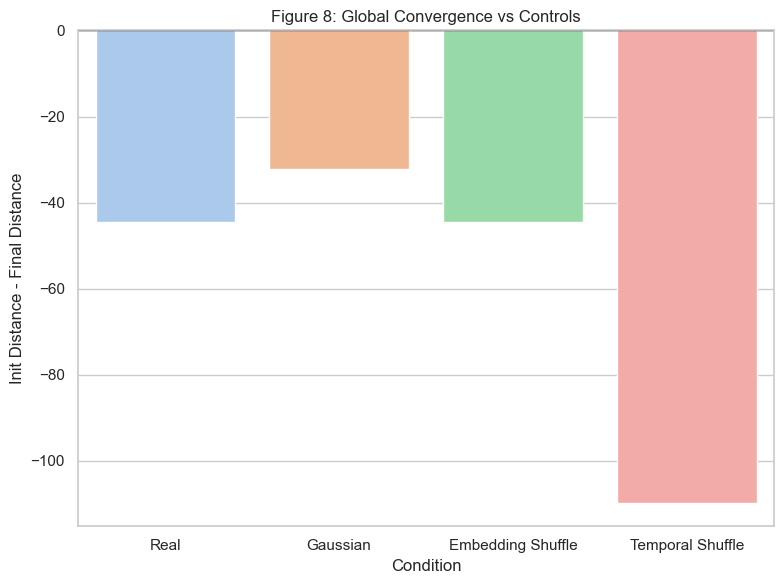

In [9]:
def avg_convergence_overall(trajectories):
    if not trajectories: return 0.0
    cm = compute_convergence_matrix(trajectories)
    triu_idx = np.triu_indices_from(cm, k=1)
    return np.mean(cm[triu_idx]) if len(cm[triu_idx]) > 0 else 0.0

control_records = [
    {"Condition": "Real", "Convergence": avg_convergence_overall(real_trajs)},
    {"Condition": "Gaussian", "Convergence": avg_convergence_overall(gaussian_trajs)},
    {"Condition": "Embedding Shuffle", "Convergence": avg_convergence_overall(shuffled_trajs)},
    {"Condition": "Temporal Shuffle", "Convergence": avg_convergence_overall(temporal_trajs)}
]
df_controls = pd.DataFrame(control_records)

plt.figure(figsize=(8, 6))
sns.barplot(data=df_controls, x="Condition", y="Convergence", palette="pastel")
plt.axhline(0, color="black", linewidth=1)
plt.title("Figure 8: Global Convergence vs Controls")
plt.ylabel("Init Distance - Final Distance")
plt.tight_layout()
plt.savefig("../figures/Figure8_ControlConvergence.png", dpi=300)
plt.show()

## Section 9: Trajectory Velocity
Which layer transitions exhibit the largest representational shift?

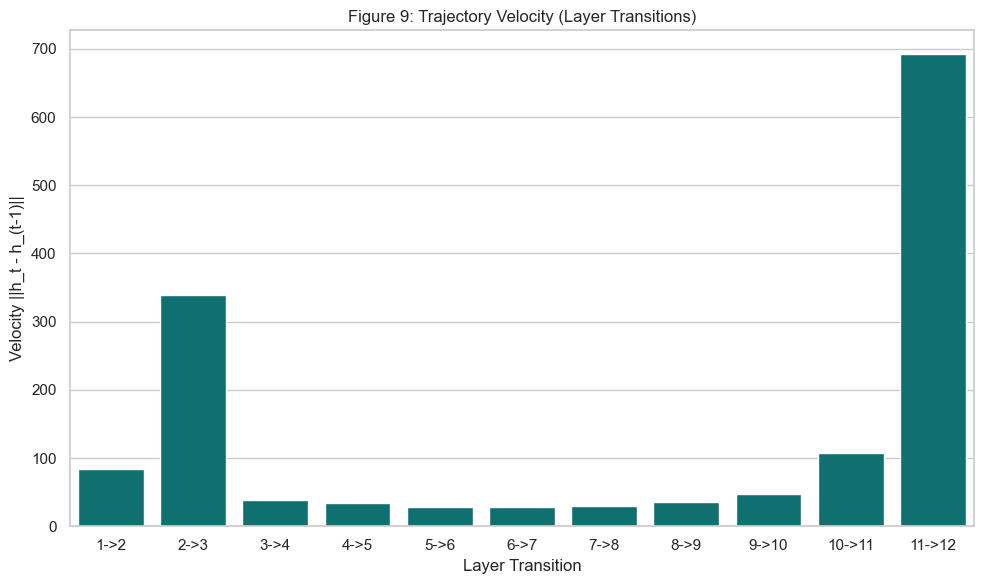

In [10]:
from src.metrics import compute_layer_velocity

velocities = compute_layer_velocity(real_trajs)
df_vel = pd.DataFrame({
    "Layer Transition": [f"{l}->{l+1}" for l in range(1, num_layers)],
    "Velocity": velocities
})

plt.figure(figsize=(10, 6))
sns.barplot(data=df_vel, x="Layer Transition", y="Velocity", color="teal")
plt.title("Figure 9: Trajectory Velocity (Layer Transitions)")
plt.ylabel("Velocity ||h_t - h_(t-1)||")
plt.tight_layout()
plt.savefig("../figures/Figure9_Velocity.png", dpi=300)
plt.show()

## Section 10: Critical Layer Detection
Identifying the "Critical Layer" where representations reorganize the most.

In [11]:
critical_layer_vel = np.argmax(velocities) + 1  # Index 0 is transition 1->2
print(f"Critical Layer (Max Velocity): Layer {critical_layer_vel} -> {critical_layer_vel+1}")

# Extract correlation of consecutive layers from RSA matrix
consecutive_rsa = [rsa_matrix[i, i+1] for i in range(num_layers-1)]
critical_layer_rsa = np.argmin(consecutive_rsa) + 1 # Min correlation = max drift
print(f"Critical Layer (Max RSA Drift): Layer {critical_layer_rsa} -> {critical_layer_rsa+1}")

pd.DataFrame({
    "Metric": ["Velocity Peak", "RSA Drift Peak"],
    "Critical Layer Transition": [f"{critical_layer_vel}->{critical_layer_vel+1}", f"{critical_layer_rsa}->{critical_layer_rsa+1}"]
}).to_csv("../results/metrics/critical_layers.csv", index=False)

Critical Layer (Max Velocity): Layer 11 -> 12
Critical Layer (Max RSA Drift): Layer 11 -> 12


## Section 11 & 12: Statistical Testing & Final Results Table
Validating length, curvature, convergence, and RSA Stability against random gaussian and shuffled controls.

In [12]:
def get_metrics_array(trajectories, metric_func):
    if not trajectories: return np.array([])
    return metric_func(trajectories)

def get_convergence_scores(trajectories):
    if not trajectories: return np.array([])
    cm = compute_convergence_matrix(trajectories)
    return np.mean(cm, axis=1) if len(cm) > 0 else np.array([])

def get_rsa_stability(trajectories):
    if not trajectories: return np.array([])
    # using average column correlation as stability proxy for testing
    rm = compute_rsa_matrix(trajectories)
    return np.mean(rm, axis=1) if len(rm) > 0 else np.array([])

real_len = get_metrics_array(real_trajs, compute_trajectory_length)
gauss_len = get_metrics_array(gaussian_trajs, compute_trajectory_length)
shuff_len = get_metrics_array(shuffled_trajs, compute_trajectory_length)

real_curv = get_metrics_array(real_trajs, compute_curvature)
gauss_curv = get_metrics_array(gaussian_trajs, compute_curvature)
shuff_curv = get_metrics_array(shuffled_trajs, compute_curvature)

real_conv = get_convergence_scores(real_trajs)
gauss_conv = get_convergence_scores(gaussian_trajs)
shuff_conv = get_convergence_scores(shuffled_trajs)

real_rsa = get_rsa_stability(real_trajs)
gauss_rsa = get_rsa_stability(gaussian_trajs)
shuff_rsa = get_rsa_stability(shuffled_trajs)

stats_records = []

for name, real_vals, shuff_vals, gauss_vals in [
    ("Length", real_len, shuff_len, gauss_len),
    ("Curvature", real_curv, shuff_curv, gauss_curv),
    ("Convergence", real_conv, shuff_conv, gauss_conv),
    ("RSA Stability", real_rsa, shuff_rsa, gauss_rsa)
]:
    if len(real_vals) > 0 and len(shuff_vals) > 0 and len(gauss_vals) > 0:
        r_mean = np.mean(real_vals)
        s_mean = np.mean(shuff_vals)
        g_mean = np.mean(gauss_vals)
        
        p_shuff = permutation_test(real_vals, shuff_vals)
        p_gauss = permutation_test(real_vals, gauss_vals)
        d_shuff = cohens_d(real_vals, shuff_vals)
        d_gauss = cohens_d(real_vals, gauss_vals)
        ci_real = bootstrap_ci(real_vals)
        
        stats_records.append({
            "Metric": name,
            "Real Mean": r_mean,
            "Real 95% CI": ci_real,
            "Shuffle Mean": s_mean,
            "Gaussian Mean": g_mean,
            "p-value (vs Shuffle)": p_shuff,
            "Cohen's d (vs Shuffle)": d_shuff,
            "p-value (vs Gaussian)": p_gauss,
            "Cohen's d (vs Gaussian)": d_gauss
        })

df_stats = pd.DataFrame(stats_records)
df_stats.to_csv("../results/metrics/statistics_summary.csv", index=False)
display(df_stats)

,Metric,Real Mean,Real 95% CI,Shuffle Mean,Gaussian Mean,p-value (vs Shuffle),Cohen's d (vs Shuffle),p-value (vs Gaussian),Cohen's d (vs Gaussian)
0,Length,1463.529541,"(874.582275390625, 2061.6005859375)",7242.056152,11235.196289,0.0,-1.460383e+00,0.0000,-3.767081
1,Curvature,1.139194,"(1.0674178309738636, 1.1998003262281418)",1.990266,2.051848,0.0,-4.231984e+00,0.0000,-3.262342
2,Convergence,-43.509278,"(-47.069424318885794, -40.430637132153514)",-43.509278,-31.594930,1.0,2.293433e-16,0.0085,-0.531202
3,RSA Stability,0.945769,"(0.931988550099861, 0.9545100958725017)",0.081570,0.088097,0.0,3.956689e+01,0.0000,48.412174
